In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [70]:
dataset = pd.read_csv('./data/titanic_modified_dataset.csv',index_col='PassengerId')
dataset

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Survived
PassengerId,,,,,,,,,
1,3,0,22.0,1,0,7.2500,0,0,0
2,1,1,38.0,1,0,71.2833,1,1,1
3,3,1,26.0,0,0,7.9250,0,2,1
4,1,1,35.0,1,0,53.1000,0,1,1
5,3,0,35.0,0,0,8.0500,0,0,0
...,...,...,...,...,...,...,...,...,...
887,2,0,27.0,0,0,13.0000,0,5,0
888,1,1,19.0,0,0,30.0000,0,2,1
889,3,1,28.0,1,2,23.4500,0,2,0


In [71]:
data_arr=dataset.to_numpy().astype(np.float64)
data_arr
X,y=data_arr[:, :-1],data_arr[:, -1]
X,y 

(array([[ 3.    ,  0.    , 22.    , ...,  7.25  ,  0.    ,  0.    ],
        [ 1.    ,  1.    , 38.    , ..., 71.2833,  1.    ,  1.    ],
        [ 3.    ,  1.    , 26.    , ...,  7.925 ,  0.    ,  2.    ],
        ...,
        [ 3.    ,  1.    , 28.    , ..., 23.45  ,  0.    ,  2.    ],
        [ 1.    ,  0.    , 26.    , ..., 30.    ,  1.    ,  0.    ],
        [ 3.    ,  0.    , 32.    , ...,  7.75  ,  2.    ,  0.    ]],
       shape=(891, 8)),
 array([0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0.,
        1., 0., 1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0.,
        0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0.,
        0., 1., 1., 0., 1., 1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 1.,
        1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0.,
        0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 

In [72]:
intercept = np.ones((X.shape[0], 1))
X_b = np.concatenate((intercept, X), axis=1)
X_b

array([[ 1.    ,  3.    ,  0.    , ...,  7.25  ,  0.    ,  0.    ],
       [ 1.    ,  1.    ,  1.    , ..., 71.2833,  1.    ,  1.    ],
       [ 1.    ,  3.    ,  1.    , ...,  7.925 ,  0.    ,  2.    ],
       ...,
       [ 1.    ,  3.    ,  1.    , ..., 23.45  ,  0.    ,  2.    ],
       [ 1.    ,  1.    ,  0.    , ..., 30.    ,  1.    ,  0.    ],
       [ 1.    ,  3.    ,  0.    , ...,  7.75  ,  2.    ,  0.    ]],
      shape=(891, 9))

In [73]:
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=val_size, random_state=random_state, shuffle=is_shuffle)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=test_size, random_state=random_state, shuffle=is_shuffle)
X_train.shape, X_val.shape, X_test.shape

((623, 8), (179, 8), (89, 8))

In [74]:
normalizer = StandardScaler()
# Normalize TẤT CẢ các cột (vì chưa có bias)
X_train = normalizer.fit_transform(X_train)
X_val = normalizer.transform(X_val)
X_test = normalizer.transform(X_test)

# Thêm bias SAU KHI normalize
X_train = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1)
X_val = np.concatenate([np.ones((X_val.shape[0], 1)), X_val], axis=1)
X_test = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)

In [75]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def predict(X,theta):
    dot_product = np.dot(X,theta)
    return sigmoid(dot_product)

def loss(y_hat,y):
    y_hat = np.clip(y_hat,1e-15,1-1e-15)
    return -np.mean(y*np.log(y_hat)+(1-y)*np.log(1-y_hat))

def compute_gradient(X,y,y_hat):
    return np.dot(X.T,y_hat-y)/len(y)

def update_theta(theta,gradient,learning_rate):
    return theta-gradient*learning_rate

def accuracy(X, y, theta):  # ✅ Thêm tham số X
    y_hat = predict(X, theta)  # ✅ Dùng X từ tham số
    y_hat = np.round(y_hat)
    return np.mean(y_hat==y)

In [76]:
lr = 0.01
epochs = 1000
batch_size = 16

np.random.seed(random_state)
theta = np.zeros(X_train.shape[1])  # ✅ Dùng X_train thay vì X_b

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    train_batch_losses =[]
    train_batch_accs = []
    val_batch_losses = []
    val_batch_accs = []

    for i in range(0, X_train.shape[0], batch_size):
        X_i = X_train[i:i+batch_size]
        y_i = y_train[i:i+batch_size]
        
        y_hat = predict(X_i,theta)
        
        train_loss = loss(y_hat,y_i)

        gradient = compute_gradient(X_i,y_i,y_hat)
        
        theta = update_theta(theta,gradient,lr)
        
        train_batch_losses.append(train_loss)
        train_acc = accuracy(X_i, y_i, theta)  # ✅ Truyền X_i thay vì y_hat
        train_batch_accs.append(train_acc)

        y_val_hat = predict(X_val,theta)
        val_loss = loss(y_val_hat,y_val)
        val_batch_losses.append(val_loss)
        val_acc = accuracy(X_val, y_val, theta)  # ✅ Truyền X_val
        val_batch_accs.append(val_acc)

    train_batch_loss = sum(train_batch_losses)/len(train_batch_losses)
    train_batch_acc = sum(train_batch_accs)/len(train_batch_accs)
    val_batch_loss = sum(val_batch_losses)/len(val_batch_losses)
    val_batch_acc = sum(val_batch_accs)/len(val_batch_accs)

    train_losses.append(train_batch_loss)
    val_losses.append(val_batch_loss)
    train_accs.append(train_batch_acc)
    val_accs.append(val_batch_acc)

    if (epoch+1) % 100 == 0:  # ✅ In mỗi 100 epochs thay vì mỗi batch
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_batch_loss:.4f}, Train Acc: {train_batch_acc:.4f}, Val Loss: {val_batch_loss:.4f}, Val Acc: {val_batch_acc:.4f}')

Epoch 100/1000, Train Loss: 0.4121, Train Acc: 0.8169, Val Loss: 0.5200, Val Acc: 0.7654
Epoch 200/1000, Train Loss: 0.4114, Train Acc: 0.8169, Val Loss: 0.5244, Val Acc: 0.7697
Epoch 300/1000, Train Loss: 0.4113, Train Acc: 0.8169, Val Loss: 0.5251, Val Acc: 0.7725
Epoch 400/1000, Train Loss: 0.4113, Train Acc: 0.8169, Val Loss: 0.5252, Val Acc: 0.7730
Epoch 500/1000, Train Loss: 0.4113, Train Acc: 0.8169, Val Loss: 0.5253, Val Acc: 0.7734
Epoch 600/1000, Train Loss: 0.4113, Train Acc: 0.8169, Val Loss: 0.5253, Val Acc: 0.7735
Epoch 700/1000, Train Loss: 0.4113, Train Acc: 0.8169, Val Loss: 0.5253, Val Acc: 0.7735
Epoch 800/1000, Train Loss: 0.4113, Train Acc: 0.8169, Val Loss: 0.5253, Val Acc: 0.7735
Epoch 900/1000, Train Loss: 0.4113, Train Acc: 0.8169, Val Loss: 0.5253, Val Acc: 0.7735
Epoch 1000/1000, Train Loss: 0.4113, Train Acc: 0.8169, Val Loss: 0.5253, Val Acc: 0.7735


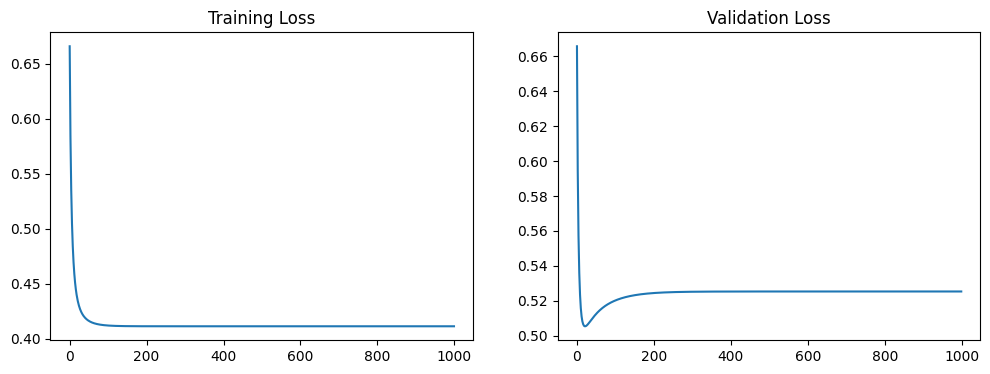

In [77]:
fig,ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(train_losses)
ax[0].set_title('Training Loss')
ax[1].plot(val_losses)
ax[1].set_title('Validation Loss')
plt.show()  

In [78]:
val_set_acc = accuracy(X_val, y_val, theta)
test_set_acc = accuracy(X_test, y_test, theta)
print('Evaluation on validation and test set:')
print(f'Accuracy: {val_set_acc}')
print(f'Accuracy: {test_set_acc}')

Evaluation on validation and test set:
Accuracy: 0.776536312849162
Accuracy: 0.7865168539325843
